In [1]:
import ROOT
import warnings

import numpy as np
import matplotlib.pyplot as plt

from scipy import integrate
from lmfit import Parameters, minimize

from scipy.optimize import curve_fit 

from scipy.special import gamma

from pyazr import azure2

from SRIM import SRIM

warnings.filterwarnings('ignore')

# Boltzmann constant in keV/K
k = 8.617e-5

# Doppler effect
dopp = np.sqrt( 2 * 1.007 / 19 * 0.250 * k * ( 80 + 273 ) )

print( 'Doppler effect =', dopp )

Doppler effect = 0.02839149987232094


In [2]:
# Read the element stopping data
H_in_F = SRIM( "stopping/H_in_F.stop" )
H_in_H = SRIM( "stopping/H_in_H.stop" )
H_in_Fe = SRIM( "stopping/H_in_Fe.stop" )
H_in_Ta = SRIM( "stopping/H_in_Ta.stop" )
H_in_Ca = SRIM( "stopping/H_in_Ca.stop" )

In [3]:
# Get the effective stopping power for CaF2
def effective_stopping_CaF2( energy, n_inactive=1, n_active=2 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Ca.eval( energy )

# Get the effective stopping power for F implanted in Fe
def effective_stopping_Fe( energy, n_inactive=1, n_active=3 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Fe.eval( energy )

# Get the effective stopping power for F implanted in Ta
def effective_stopping_Ta( energy, n_inactive=1, n_active=5 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Ta.eval( energy )

       Target  RunID           E             Y   Y_error
0      SUDF#4    728  329.177866    344.221100  0.014250
1      SUDF#4    729  332.104128    603.196226  0.020014
2      SUDF#4    731  335.118794   1144.985836  0.023518
3      SUDF#4    732  339.059215   5060.570416  0.046812
4      SUDF#4    733  342.061961  22749.276270  0.157499
..        ...    ...         ...           ...       ...
73  IMP_LTA#2   1510  336.996131    781.722026  0.021037
74  IMP_LTA#2   1511  333.996365    410.813761  0.016506
75  IMP_LTA#2   1512  331.999832    235.261900  0.012087
76  IMP_LTA#2   1513  330.003299    199.600753  0.011856
77  IMP_LTA#2   1514  336.002831    638.133465  0.020381

[78 rows x 5 columns]


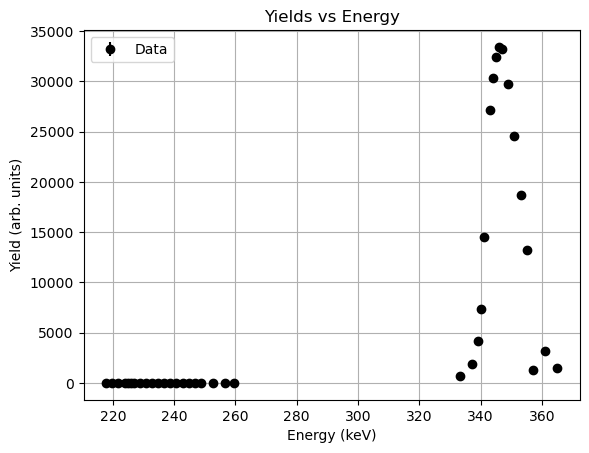

In [4]:
import pandas as pd

# Load csv data from Yields.csv
df = pd.read_csv( 'Yields.csv' )

print(df)

# Mask SUDFLUOR#3 target
mask = df['Target'] == 'IMP_LFE#2'

x, y, yerr = df['E'][mask], df['Y'][mask], df['Y_error'][mask]

x = x.to_numpy()
y = y.to_numpy()
yerr = yerr.to_numpy()

# Plot the data
plt.errorbar( x, y, yerr=yerr, fmt='o', label='Data', color='black' )
plt.xlabel( 'Energy (keV)' )
plt.ylabel( 'Yield (arb. units)' )
plt.title( 'Yields vs Energy' )
plt.legend()
plt.grid()
plt.show()

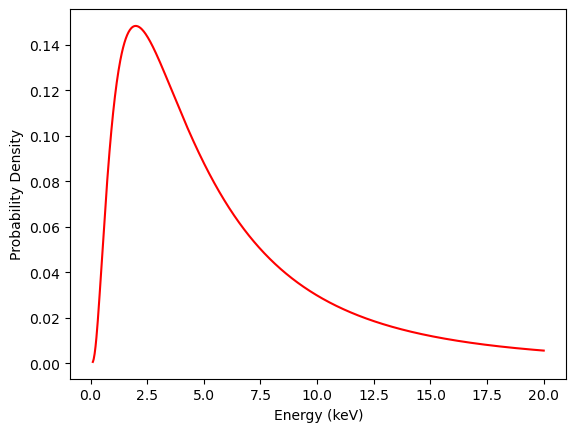

In [5]:
# Plot a lognormal distribution
def lognormal(x, mu, sigma):
    return (1 / (x * sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((np.log(x) - mu) / sigma) ** 2)

x_dist = np.linspace(0.1, 20, 1000)
mu, sigma = np.log(10), 0.5
y_dist = lognormal(x_dist, 1.5, 0.9)
plt.plot(x_dist, y_dist, label='Lognormal Distribution', color='red')
plt.xlabel('Energy (keV)')
plt.ylabel('Probability Density')
plt.show( )

In [6]:
azr = azure2( "20Ne.azr", nprocs=1 )
azr.extrap_mode( )

Calculating Lo-Matrix, Phases, and Penetrabilities...
Calculating Legendre Polynomials...
Calculating Coulomb Amplitudes...
Calculating External Capture Amplitudes...
Initializing Component Segments...
Initializing Component Segments (0 components)...
Calculating EC Amplitudes for Component Segments...


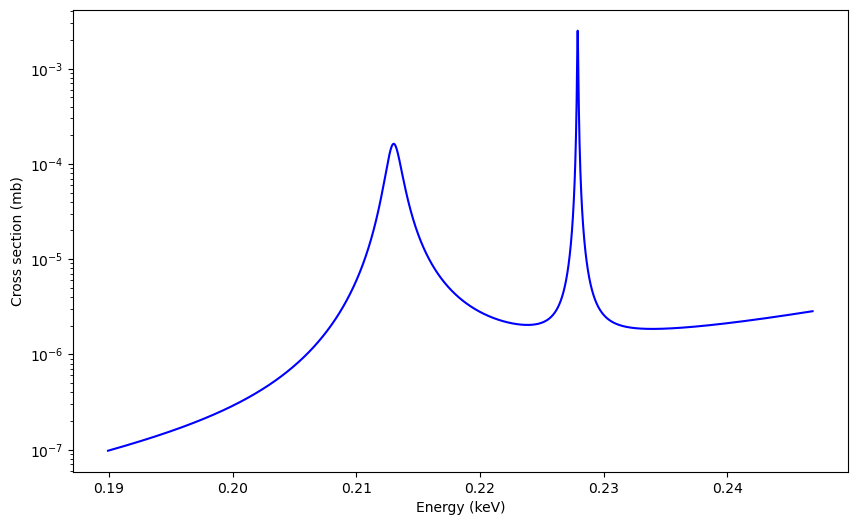

In [7]:
azr_params = [13.057, 1282.52, 13.0719, 9.5e-3, 80]

segments = azr.calculate( azr_params )
energies = azr.calculate_energies( azr_params )

plt.figure( figsize=( 10, 6 ) )

plt.plot( energies[0], segments[0], label='20Ne', color='blue' )
plt.xlabel( 'Energy (keV)' )
plt.ylabel( 'Cross section (mb)' )

plt.yscale( 'log' )

plt.show( )

In [8]:
popt = [0.75324712]
def straggling( x ):
    return popt[0] * np.sqrt( x )

In [9]:
segments = []
energies = []
DeltaE = 12 # keV

def gaussian( x, x0, s ):
    return ( 1. / ( np.sqrt(2.*np.pi) * s ) ) * np.exp( -(x - x0)**2 / ( s*s*2 ) )

def profile( de, theta ):
    # Truncated gaussian distribution
    if de <= 0:
        return 0
    else:
        return gaussian( 5.5, de, 5.2 )


    #return gaussian( 1, de, 10 )
    #return 1 if de > 0 and de < 12 else 0

def cross_section( x0, theta, de ):
    cross = np.interp( x0, energies[0] * 1e3, segments[0] )
    return cross * profile( de, theta )

def integrand( x, theta, x0 ):
    de = x0 - x
    
    # Get beam width
    s = np.sqrt( pow( theta[0], 2 ) + pow( dopp, 2 ) )
    s = np.sqrt( pow( straggling( de ), 2 ) + pow(s, 2) ) if de > 0 else s

    # Convolve the gaussian with the straggling
    array = np.linspace( x - 3 * s, x + 3 * s, 1000 )
    gauss = gaussian( array, x, s )

    # Normalize the gaussian
    step = array[1] - array[0]
    norm  = np.sum( gauss ) * step
    
    # Convolve
    conv = np.sum( gauss * cross_section( array, theta, de ) ) * step / norm

    return conv

def straggled_profile( x, theta ):
    y = np.zeros( shape=len( x ) )
    for idx in range( len( x ) ):
        xmin, xmax = x[idx] - DeltaE, x[idx]
        nsteps = 1000
        dx = np.abs( xmax - xmin ) / nsteps
        y[idx] = integrate.simpson( [ integrand( x_i, theta, x[idx] ) for x_i in np.linspace( xmin, xmax, nsteps) ], dx=dx )
    return y

def model( x, theta ):
    global segments, energies
    segments = azr.calculate( azr_params )
    energies = azr.calculate_energies( azr_params )
    sign = straggled_profile( x, theta[:-1] )
    back = theta[-1]
    return sign + back

def chi2( theta ):
    theta = list( theta.valuesdict().values() )
    mod   = model( x, theta )
    res   = ( obs - mod ) / err
    print( "Chi2: {:10.4f}".format(np.sum(res**2)), end="\r" )
    return res

In [10]:
params = Parameters()
params.add('beam',    value=0.12,    vary=False)
params.add('width',   value=0.007,   vary=False)
params.add('edge',    value=210,     vary=True)
params.add('height',  value=0.078,   vary=True, min=0)
params.add('oxide',   value=0,       vary=True, min=0, max=0.5)
params.add('slope',   value=7.5,     vary=True, min=0, max=200)
params.add('scale',   value=1,       vary=False)
params.add('back',    value=0,       vary=True)

azr_params = [13.057, 1282.52, 13.0680, 8.6e-4, 90]

theta = list( params.valuesdict().values() )

grid = np.linspace( 205, 250, 100 )

mod = model( grid, theta )

2.71854e-07 4249999999999.9995 [ 0.86815849  0.94278104  1.0289793   1.12944245  1.2477196   1.3885803
  1.55857083  1.76690184  2.02692093  2.35867246  2.79360456  3.38384044
  4.22204691  5.48839797  7.56982099 11.30980075 18.14357438 29.13810423
 41.64274281 51.21769568 57.90872445 63.03136523 67.21918551 70.71692468
 73.61796713 75.95564934 77.73856252 78.9646332  79.63147945 79.74389788
 79.31082407 78.34451547 76.86139103 74.88255447 72.43430039 69.54878261
 66.26497582 62.6299783  58.70129145 54.57907698 50.58179962 47.47346291
 45.9780162  42.42259239 38.62096113 34.99867198 31.62555688 28.54631817
 25.78678533 23.35710575 21.25096161 19.45048025 17.9217022  16.63160291
 15.54337056 14.61625521 13.81508062 13.10738874 12.46566484 11.86831647
 11.29897227 10.74739147 10.20714032  9.67371656  9.14611367  8.62745397
  8.12374244  7.64202272  7.19008791  6.77496621  6.40278719  6.07792543
  5.80282398  5.57783546  5.40135742  5.27018841  5.17987441  5.12531299
  5.10113116  5.10212

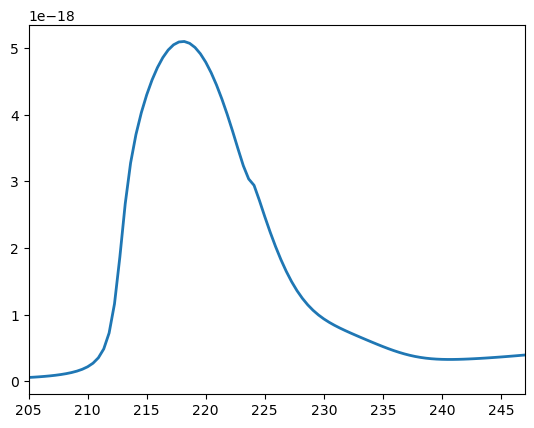

In [11]:
scale = 1.61e6

# barn = 1e-24 cm2
# stop = eV / (1E15 atoms/cm2) = (eV * cm2) / 1E15 atoms

eff = 0.68

stop = effective_stopping_Fe( 220, 10, 1 ) * 1e15 * 1e-24
scale = 1e-6 / (1.6 * 1e-19) * eff
print( stop, scale, mod / stop )

plt.plot( grid, mod / scale, '-', lw=2 )
# plt.errorbar( x * 19 / 20.007 - 1, y / scale, yerr=yerr / scale, fmt='o', label='Data', color='black' )

# Plot cross section with the same scale
grid_cross = np.linspace( 205, 250, 10000 )
y_cross = np.interp( grid_cross, energies[0] * 1e3, segments[0] )
y_cross = y_cross / np.max( y_cross ) * np.max( mod ) * 0.9
# plt.plot( grid_cross, y_cross, '--', lw=2, label='Cross Section' )

# Print the value of the parameters
energy_1 = (azr_params[0] - 12.844) * 20.007 / 19 * 1e3
energy_2 = (azr_params[2] - 12.844) * 20.007 / 19 * 1e3

#plt.text( 230, 2.2e-5, r'$E_1$ = {:6.3f} keV'.format( energy_1 ), fontsize=14 )
#plt.text( 230, 2.0e-5, r'$E_2$ = {:6.3f} keV'.format( energy_2 ), fontsize=14 )

plt.xlim(205, 247)
# plt.ylim(0, 1e-11)

plt.show( )

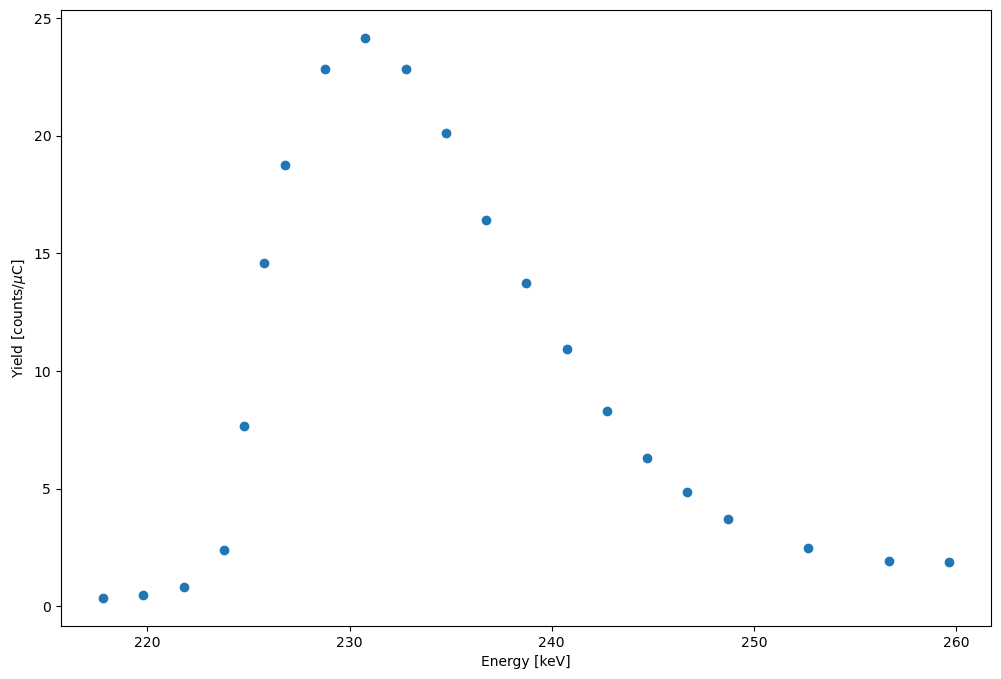

[0.00574486 0.00577811 0.00582336 0.0058699  0.0058935  0.00591746
 0.00594164 0.00596611 0.00599097 0.00601616 0.00604156 0.00606739
 0.00609354 0.00612013 0.00614688 0.00616048 0.00617409 0.00618787
 0.00621562 0.00624376 0.00627218]


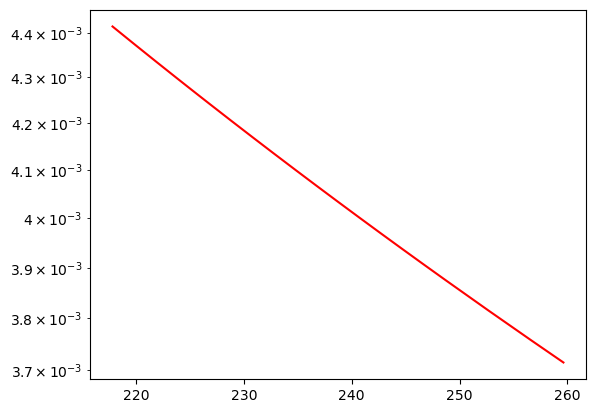

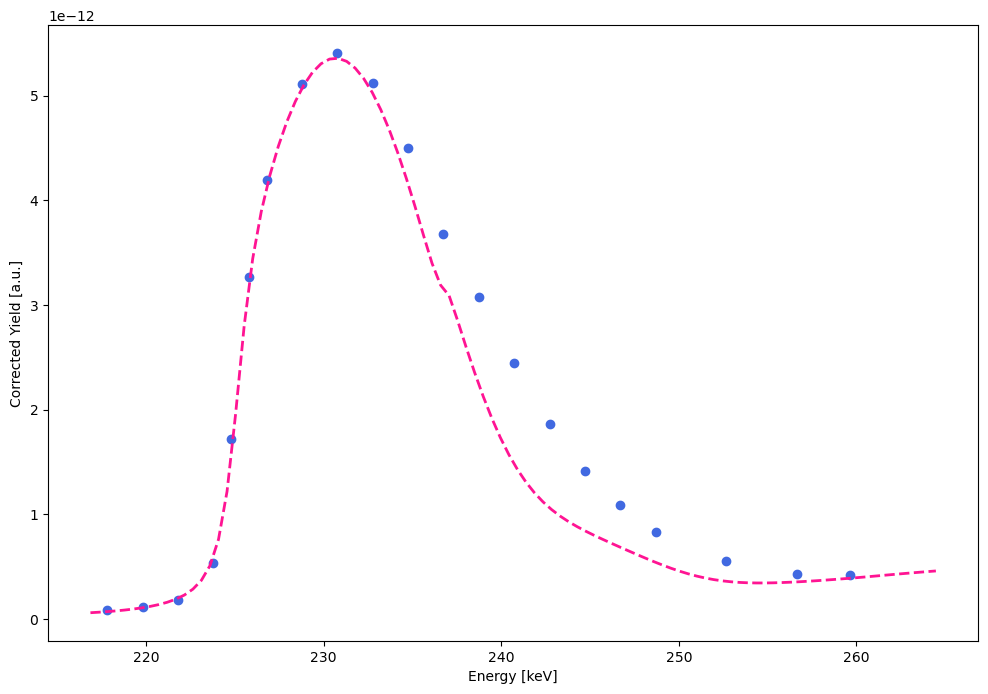

In [12]:
### Qui ho aggiunto codice mio per fare test e fittare un profilo ###

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

target = "IMP_LFE#2"
# target = "SUDF#4"
# target = "EVA_AT#3"

# Read the CSV file of yield for the target
df = pd.read_csv(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Scripts/Data/Yield/Yield_csv/Yield_{target}.csv")
# print(df)

# Recover the very first scan
E, Y, Y_err = df["E_scan1"], df["Y_scan1"], df["Y_error_scan1"]

# Refine the yield data by selecting only points with E not NaN and E>300 keV
mask = (~np.isnan(E)) & (E < 300)
E = E[mask]
Y = Y[mask]
Y_err = Y_err[mask]

# Plot the yield profile
plt.figure(figsize=(12,8))
plt.scatter(E, Y)
plt.xlabel("Energy [keV]")
plt.ylabel(r"Yield [counts/$\mu$C]")
plt.show()

# Correct all the yield of the profile
efficiency = 68/100     # Efficiency in close geometry
# efficiency = 0.44/100 # Efficiency in far geometry
w = 1
branching = 95/100
uC_to_particles = 1.6022e-13
Y = Y / efficiency * w * branching * uC_to_particles

Z0, Z1 = 1, 19
M0 = 1.0078250 # amu projectile H
M1 = 18.998403 # amu target F
eta = (0.98951013 * Z0 * Z1 * np.sqrt( (M0*M1)/(M0+M1) / np.array(E)/1000 )) / (2 * np.pi)
print(eta)
direct_capture = 1/E * np.exp(-2*np.pi*eta)

plt.yscale('log')
plt.plot(E, direct_capture, label='Direct Capture', color='red')
plt.show()

# Plot the corrected yield profile
plt.figure(figsize=(12,8))
plt.scatter(E, Y, color="royalblue")
scale = 4249999.9999999995
plt.plot( grid*20/19 * 1.005, mod / scale * 1.05, '-', lw=2, color="deeppink", ls="--" )
plt.xlabel("Energy [keV]")
plt.ylabel(r"Corrected Yield [a.u.]")
plt.savefig(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Scripts/Yield_Profile__FITTED{target}.png", dpi=300, bbox_inches='tight')
plt.show()